# 

Portfolio Risk Analysis and Optimization

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.optimize import brentq, minimize
from scipy.stats import norm

DATA_FILE = Path("datas_apple_amazon_facebook.xlsx") # modificata
SHEET_NAME = "Sheet1"
SKIP_ROWS = 3                 
TAIL_PROBABILITY = 0.01       
TARGET_VAR = 28.0
INITIAL_CAPITAL = 10_000.0    # capitale ipotetico del portafoglio, in dollari


IMAGE_DIR = Path("images")
IMAGE_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

In [2]:
def load_prices(file_path: Path) -> pd.DataFrame:
    """Importa e valida i prezzi dal foglio Excel."""
    if not file_path.exists():
        raise FileNotFoundError(
            f"File non trovato: {file_path}\n"
            "Inserisci datas_apple_amazon_facebook.xlsx nella stessa cartella dello script."
        )

    raw = pd.read_excel(
        file_path,
        sheet_name=SHEET_NAME,
        skiprows=SKIP_ROWS,
        usecols="A:D",
        engine="openpyxl",
    )

    if raw.shape[1] != 4:
        raise ValueError("Il foglio deve contenere quattro colonne: Date e tre prezzi.")

    raw.columns = ["Date", "Apple", "Amazon", "Meta"]
    raw["Date"] = pd.to_datetime(raw["Date"], errors="coerce")

    asset_columns = ["Apple", "Amazon", "Meta"]
    raw[asset_columns] = raw[asset_columns].apply(pd.to_numeric, errors="coerce")
    prices = (
        raw.dropna(subset=["Date", *asset_columns])
        .drop_duplicates(subset="Date", keep="last")
        .sort_values("Date")
        .set_index("Date")
    )

    if len(prices) < 2:
        raise ValueError("Non ci sono abbastanza osservazioni valide per calcolare i rendimenti.")
    if (prices <= 0).any().any():
        raise ValueError("I prezzi devono essere strettamente positivi.")

    return prices


def parametric_var(losses: pd.Series, p: float) -> float:
    """VaR normale: soglia superata con probabilita p."""
    return float(losses.mean() + losses.std(ddof=1) * norm.ppf(1 - p))


def parametric_es(losses: pd.Series, p: float) -> float:
    """Expected Shortfall sotto ipotesi di perdite normali."""
    z_score = norm.ppf(1 - p)
    return float(losses.mean() + losses.std(ddof=1) * norm.pdf(z_score) / p)


def historical_var(losses: pd.Series, p: float) -> float:
    """VaR stimato direttamente dalla distribuzione empirica delle perdite."""
    return float(losses.quantile(1 - p))


def historical_es(losses: pd.Series, p: float) -> float:
    """Media delle perdite storiche uguali o superiori al VaR storico."""
    var_value = historical_var(losses, p)
    tail_losses = losses[losses >= var_value]
    return float(tail_losses.mean())


def portfolio_losses(
    returns: pd.DataFrame, weights: np.ndarray, capital: float
) -> pd.Series:
    """Converte i rendimenti di portafoglio in perdite monetarie giornaliere."""
    values = -capital * returns.to_numpy() @ weights
    return pd.Series(values, index=returns.index, name="Portfolio loss")


def global_minimum_variance_weights(covariance: pd.DataFrame) -> np.ndarray:
    """Calcola i pesi GMVP con vincolo somma dei pesi uguale a 1."""
    sigma = covariance.to_numpy()
    ones = np.ones(len(covariance.columns))
    sigma_inverse_times_one = np.linalg.solve(sigma, ones)
    return sigma_inverse_times_one / (ones @ sigma_inverse_times_one)


def two_asset_var(
    weight_first: float,
    mean_first: float,
    mean_second: float,
    variance_first: float,
    variance_second: float,
    covariance: float,
    p: float,
) -> float:
    """VaR parametrico delle perdite di un portafoglio (a, 1-a)."""
    weight_second = 1.0 - weight_first
    portfolio_mean = weight_first * mean_first + weight_second * mean_second
    portfolio_variance = (
        weight_first**2 * variance_first
        + weight_second**2 * variance_second
        + 2 * weight_first * weight_second * covariance
    )
    portfolio_variance = max(float(portfolio_variance), 0.0)
    return portfolio_mean + norm.ppf(1 - p) * np.sqrt(portfolio_variance)


def find_target_var_weights(
    first_loss: pd.Series,
    second_loss: pd.Series,
    target: float,
    p: float,
    lower: float = -10.0,
    upper: float = 10.0,
    grid_size: int = 4_001,
) -> list[float]:
    """Trova tutte le radici VaR(a) = target individuate nell'intervallo."""
    aligned = pd.concat([first_loss, second_loss], axis=1).dropna()
    mean_first, mean_second = aligned.mean().to_numpy()
    covariance_matrix = aligned.cov().to_numpy()

    def difference(weight: float) -> float:
        return two_asset_var(
            weight,
            mean_first,
            mean_second,
            covariance_matrix[0, 0],
            covariance_matrix[1, 1],
            covariance_matrix[0, 1],
            p,
        ) - target

    grid = np.linspace(lower, upper, grid_size)
    values = np.array([difference(weight) for weight in grid])
    roots: list[float] = []

    for left, right, value_left, value_right in zip(
        grid[:-1], grid[1:], values[:-1], values[1:]
    ):
        if value_left == 0:
            candidate = float(left)
        elif value_left * value_right < 0:
            candidate = float(brentq(difference, left, right))
        else:
            continue

        if not roots or not np.isclose(candidate, roots[-1], atol=1e-7):
            roots.append(candidate)

    return roots


def minimum_var_weights(
    mean_losses: np.ndarray,
    covariance_losses: np.ndarray,
    p: float,
    initial_weights: np.ndarray,
    long_only: bool = False,
) -> np.ndarray:
    """Minimizza il VaR normale con il vincolo che i pesi sommino a 1."""
    z_score = norm.ppf(1 - p)

    def objective(weights: np.ndarray) -> float:
        variance = max(float(weights @ covariance_losses @ weights), 0.0)
        return float(weights @ mean_losses + z_score * np.sqrt(variance))

    constraints = {"type": "eq", "fun": lambda weights: weights.sum() - 1.0}
    bounds = [(0.0, 1.0)] * len(initial_weights) if long_only else None
    result = minimize(
        objective,
        x0=initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"ftol": 1e-12, "maxiter": 2_000},
    )

    if not result.success:
        raise RuntimeError(f"Ottimizzazione minimum-VaR non riuscita: {result.message}")
    return result.x


def print_weights(title: str, weights: np.ndarray, assets: list[str]) -> None:
    """Stampa una tabella ordinata con i pesi del portafoglio."""
    table = pd.Series(weights, index=assets, name="Weight").to_frame()
    print(f"\n{title}")
    print(table)
    print(f"Somma dei pesi: {weights.sum():.6f}")


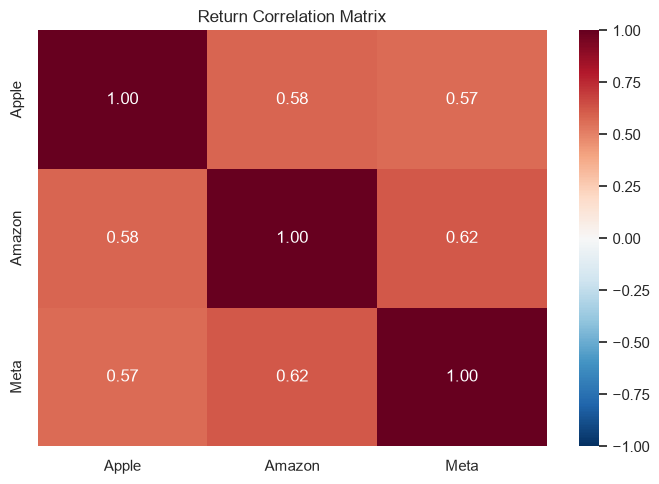

Prime osservazioni dei prezzi:
               Apple     Amazon      Meta
Date                                     
2015-10-06 27.827500 537.480000 92.800000
2015-10-07 27.695000 541.939900 92.400000
2015-10-08 27.375000 533.159900 92.470000
2015-10-09 28.030000 539.800000 93.240000
2015-10-12 27.900000 550.189900 94.260000

Statistiche descrittive dei rendimenti:
              count     mean      std       min       25%      50%      75%  \
Apple  1,299.000000 0.001252 0.018493 -0.128647 -0.005888 0.000512 0.009549   
Amazon 1,299.000000 0.001524 0.018711 -0.079221 -0.006444 0.001179 0.010116   
Meta   1,299.000000 0.000992 0.020054 -0.189609 -0.006795 0.000715 0.010585   

            max  
Apple  0.119808  
Amazon 0.132164  
Meta   0.155214  

Matrice di correlazione dei rendimenti:
          Apple   Amazon     Meta
Apple  1.000000 0.579288 0.567091
Amazon 0.579288 1.000000 0.620749
Meta   0.567091 0.620749 1.000000


In [3]:
prices = load_prices(DATA_FILE)
assets = prices.columns.tolist()

returns = prices.pct_change(fill_method=None).dropna()

losses_per_share = -prices.diff().dropna()

fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    returns.corr(),
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax
)

ax.set_title("Return Correlation Matrix")
fig.tight_layout()

fig.savefig(
    IMAGE_DIR / "correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Prime osservazioni dei prezzi:")
print(prices.head())
print("\nStatistiche descrittive dei rendimenti:")
print(returns.describe().T)
print("\nMatrice di correlazione dei rendimenti:")
print(returns.corr())

In [4]:
number_of_shares = np.array([50.0, 2.0, -20.0])
original_portfolio_value = prices @ number_of_shares
original_portfolio_loss = -original_portfolio_value.diff().dropna()

print("\nPortafoglio originale: 50 Apple, 2 Amazon, -20 Meta")
print(f"Perdita media giornaliera: {original_portfolio_loss.mean():.4f}")
print(f"Deviazione standard delle perdite: {original_portfolio_loss.std(ddof=1):.4f}")


Portafoglio originale: 50 Apple, 2 Amazon, -20 Meta
Perdita media giornaliera: -4.6762
Deviazione standard delle perdite: 84.1310


In [5]:
pair_results: list[dict[str, float | str]] = []
for first_asset, second_asset in [("Apple", "Amazon"), ("Apple", "Meta")]:
    roots = find_target_var_weights(
        losses_per_share[first_asset],
        losses_per_share[second_asset],
        target=TARGET_VAR,
        p=0.05,
    )
    for solution_number, first_weight in enumerate(roots, start=1):
        pair_results.append(
            {
                "Portfolio": f"{first_asset} + {second_asset}",
                "Solution": solution_number,
                f"Weight {first_asset}": first_weight,
                f"Weight {second_asset}": 1.0 - first_weight,
            }
        )

print("\nSoluzioni VaR = 28:")
print(pd.DataFrame(pair_results).fillna(""))


Soluzioni VaR = 28:
        Portfolio  Solution  Weight Apple Weight Amazon Weight Meta
0  Apple + Amazon         1      0.460590      0.539410            
1  Apple + Amazon         2      1.544813     -0.544813            
2    Apple + Meta         1     -4.603080                  5.603080
3    Apple + Meta         2      6.680463                 -5.680463



Pesi del Global Minimum Variance Portfolio
         Weight
Apple  0.415929
Amazon 0.359456
Meta   0.224615
Somma dei pesi: 1.000000


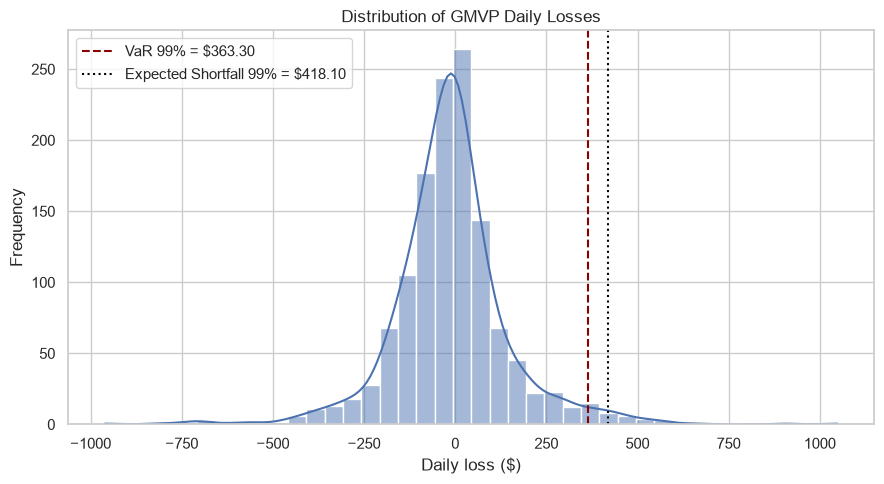


Risultati GMVP su un capitale di $10,000
Perdita media giornaliera:  $-12.91
Volatilita delle perdite:   $161.72
VaR parametrico 99%:        $363.30
ES parametrico 99%:         $418.10
VaR storico 99%:            $451.22
ES storico 99%:             $601.03


In [6]:
return_covariance = returns.cov()
gmvp_weights = global_minimum_variance_weights(return_covariance)
gmvp_losses = portfolio_losses(returns, gmvp_weights, INITIAL_CAPITAL)

print_weights("Pesi del Global Minimum Variance Portfolio", gmvp_weights, assets)

gmvp_parametric_var = parametric_var(gmvp_losses, TAIL_PROBABILITY)
gmvp_parametric_es = parametric_es(gmvp_losses, TAIL_PROBABILITY)
gmvp_historical_var = historical_var(gmvp_losses, TAIL_PROBABILITY)
gmvp_historical_es = historical_es(gmvp_losses, TAIL_PROBABILITY)

fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    gmvp_losses,
    bins=40,
    kde=True,
    ax=ax
)

ax.axvline(
    gmvp_parametric_var,
    color="darkred",
    linestyle="--",
    label=f"VaR 99% = ${gmvp_parametric_var:,.2f}"
)

ax.axvline(
    gmvp_parametric_es,
    color="black",
    linestyle=":",
    label=f"Expected Shortfall 99% = ${gmvp_parametric_es:,.2f}"
)

ax.set_title("Distribution of GMVP Daily Losses")
ax.set_xlabel("Daily loss ($)")
ax.set_ylabel("Frequency")
ax.legend()

fig.tight_layout()

fig.savefig(
    IMAGE_DIR / "loss_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"\nRisultati GMVP su un capitale di ${INITIAL_CAPITAL:,.0f}")
print(f"Perdita media giornaliera:  ${gmvp_losses.mean():,.2f}")
print(f"Volatilita delle perdite:   ${gmvp_losses.std(ddof=1):,.2f}")
print(f"VaR parametrico 99%:        ${gmvp_parametric_var:,.2f}")
print(f"ES parametrico 99%:         ${gmvp_parametric_es:,.2f}")
print(f"VaR storico 99%:            ${gmvp_historical_var:,.2f}")
print(f"ES storico 99%:             ${gmvp_historical_es:,.2f}")

In [7]:
daily_mean = gmvp_losses.mean()
daily_std = gmvp_losses.std(ddof=1)
z_score = norm.ppf(1 - TAIL_PROBABILITY)

scaling_results = []
for label, horizon in [("Daily", 1), ("Weekly", 5), ("Annual", 252)]:
    scaled_var = horizon * daily_mean + np.sqrt(horizon) * daily_std * z_score
    scaling_results.append({"Horizon": label, "Days": horizon, "VaR 99%": scaled_var})

scaling_table = pd.DataFrame(scaling_results).set_index("Horizon")
print("\nVaR parametrico su diversi orizzonti:")
print(scaling_table)



VaR parametrico su diversi orizzonti:
         Days      VaR 99%
Horizon                   
Daily       1   363.298119
Weekly      5   776.671144
Annual    252 2,718.304565



Pesi del portafoglio minimum-VaR (short selling consentito)
         Weight
Apple  0.414852
Amazon 0.372972
Meta   0.212176
Somma dei pesi: 1.000000

Pesi del portafoglio minimum-VaR (long-only)
         Weight
Apple  0.414852
Amazon 0.372972
Meta   0.212176
Somma dei pesi: 1.000000

Confronto tra portafogli:
                       Mean daily loss  Loss volatility  Parametric VaR 99%  \
Portfolio                                                                     
GMVP                        -12.912093       161.717092          363.298119   
Minimum-VaR                 -12.981216       161.731949          363.263559   
Minimum-VaR long-only       -12.981216       161.731949          363.263559   

                       Parametric ES 99%  
Portfolio                                 
GMVP                          418.098599  
Minimum-VaR                   418.069074  
Minimum-VaR long-only         418.069074  


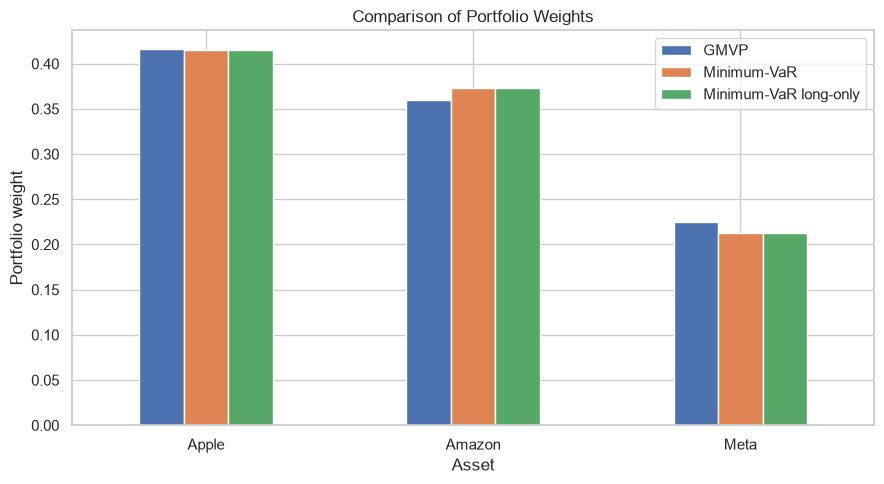

In [8]:
asset_losses = -INITIAL_CAPITAL * returns
mean_asset_losses = asset_losses.mean().to_numpy()
covariance_asset_losses = asset_losses.cov().to_numpy()

minimum_var_unconstrained_weights = minimum_var_weights(
    mean_asset_losses,
    covariance_asset_losses,
    TAIL_PROBABILITY,
    gmvp_weights,
    long_only=False,
)
minimum_var_long_only_weights = minimum_var_weights(
    mean_asset_losses,
    covariance_asset_losses,
    TAIL_PROBABILITY,
    np.repeat(1 / len(assets), len(assets)),
    long_only=True,
)

minimum_var_unconstrained_losses = portfolio_losses(
    returns, minimum_var_unconstrained_weights, INITIAL_CAPITAL
)
minimum_var_long_only_losses = portfolio_losses(
    returns, minimum_var_long_only_weights, INITIAL_CAPITAL
)

print_weights(
    "Pesi del portafoglio minimum-VaR (short selling consentito)",
    minimum_var_unconstrained_weights,
    assets,
)
print_weights(
    "Pesi del portafoglio minimum-VaR (long-only)",
    minimum_var_long_only_weights,
    assets,
)

comparison = pd.DataFrame(
    {
        "Portfolio": ["GMVP", "Minimum-VaR", "Minimum-VaR long-only"],
        "Mean daily loss": [
            gmvp_losses.mean(),
            minimum_var_unconstrained_losses.mean(),
            minimum_var_long_only_losses.mean(),
        ],
        "Loss volatility": [
            gmvp_losses.std(ddof=1),
            minimum_var_unconstrained_losses.std(ddof=1),
            minimum_var_long_only_losses.std(ddof=1),
        ],
        "Parametric VaR 99%": [
            parametric_var(gmvp_losses, TAIL_PROBABILITY),
            parametric_var(minimum_var_unconstrained_losses, TAIL_PROBABILITY),
            parametric_var(minimum_var_long_only_losses, TAIL_PROBABILITY),
        ],
        "Parametric ES 99%": [
            parametric_es(gmvp_losses, TAIL_PROBABILITY),
            parametric_es(minimum_var_unconstrained_losses, TAIL_PROBABILITY),
            parametric_es(minimum_var_long_only_losses, TAIL_PROBABILITY),
        ],
    }
).set_index("Portfolio")

print("\nConfronto tra portafogli:")
print(comparison)

weights_chart = pd.DataFrame(
    {
        "GMVP": gmvp_weights,
        "Minimum-VaR": minimum_var_unconstrained_weights,
        "Minimum-VaR long-only": minimum_var_long_only_weights
    },
    index=assets
)

fig, ax = plt.subplots(figsize=(9, 5))

weights_chart.plot(
    kind="bar",
    ax=ax
)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Comparison of Portfolio Weights")
ax.set_xlabel("Asset")
ax.set_ylabel("Portfolio weight")
ax.tick_params(axis="x", rotation=0)
ax.legend()

fig.tight_layout()

fig.savefig(
    IMAGE_DIR / "portfolio_weights.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

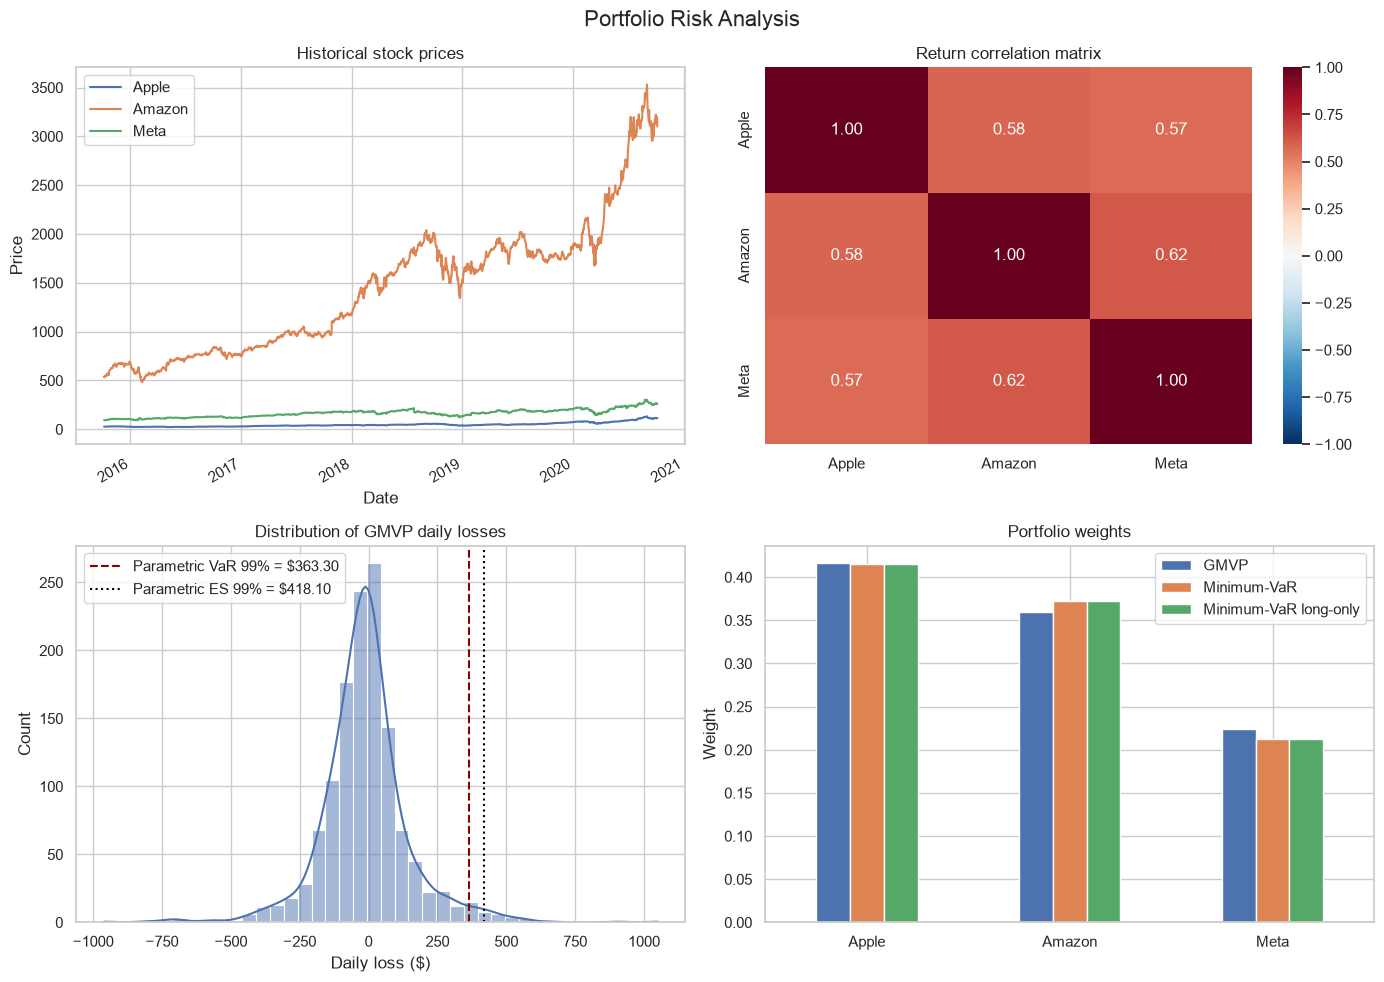

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

prices.plot(ax=axes[0, 0], title="Historical stock prices")
axes[0, 0].set_ylabel("Price")

sns.heatmap(
    returns.corr(),
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    ax=axes[0, 1],
)
axes[0, 1].set_title("Return correlation matrix")

sns.histplot(gmvp_losses, bins=40, kde=True, ax=axes[1, 0])
axes[1, 0].axvline(
    gmvp_parametric_var,
    color="darkred",
    linestyle="--",
    label=f"Parametric VaR 99% = ${gmvp_parametric_var:,.2f}",
)
axes[1, 0].axvline(
    gmvp_parametric_es,
    color="black",
    linestyle=":",
    label=f"Parametric ES 99% = ${gmvp_parametric_es:,.2f}",
)
axes[1, 0].set_title("Distribution of GMVP daily losses")
axes[1, 0].set_xlabel("Daily loss ($)")
axes[1, 0].legend()

weights_chart = pd.DataFrame(
    {
        "GMVP": gmvp_weights,
        "Minimum-VaR": minimum_var_unconstrained_weights,
        "Minimum-VaR long-only": minimum_var_long_only_weights,
    },
    index=assets,
)
weights_chart.plot(kind="bar", ax=axes[1, 1])
axes[1, 1].axhline(0, color="black", linewidth=0.8)
axes[1, 1].set_title("Portfolio weights")
axes[1, 1].set_ylabel("Weight")
axes[1, 1].tick_params(axis="x", rotation=0)

fig.suptitle("Portfolio Risk Analysis", fontsize=16)
fig.tight_layout()
plt.show()


altro 

In [10]:
from pathlib import Path

print("Cartella corrente:")
print(Path.cwd())

print("\nFile presenti:")
for file in Path.cwd().iterdir():
    print(file.name)

Cartella corrente:
/Users/benedettagatto

File presenti:
.Rhistory
.config
Music
.zprofile.pysave
.condarc
prova_notebook.ipynb
Untitled1.ipynb
.DS_Store
.CFUserTextEncoding
.xonshrc
images
Lab_0.R
Untitled.ipynb
.zshrc
melbourne_housing.py
.local
Pictures
.zprofile
ONDE.pdf
.dartServer
.pub-cache
Senza nome.R
.zsh_history
.ipython
Desktop
Library
.matplotlib
datas_apple_amazon_facebook.xlsx
.oracle_jre_usage
.spyder-py3
matlab_crash_dump.2626-1
.cups
portfolio_risk_analysis.ipynb
flutter
untitled.txt
python_150.ipynb
Public
portfolio risk analysis.ipynb
L01_lecture.ipynb
.zshenv
.idlerc
.tcshrc
.flutter
.RData
.anaconda
python.py
.dart-tool
Movies
Applications
matlab_crash_dump.2309-1
.Rapp.history
Templates
.Trash
.ipynb_checkpoints
.jupyter
Documents
Melbourne_housing.ipynb
.vscode
.bash_profile
.swiftpm
.synamedia
anaconda3
Downloads
.continuum
.cache
.gitconfig
pyfvf
.bash_history
.zsh_sessions
python_for_da.ipynb
.conda
